# Monthly Milk Production Forecasting Using RNN, LSTM, and GRU

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.seasonal import seasonal_decompose
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)


In [2]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 1.0/350.9 MB 6.3 MB/s eta 0:00:56
   ---------------------------------------- 2.4/350.9 MB 6.4 MB/s eta 0:00:55
   ---------------------------------------- 3.7/350.9 MB 6.4 MB/s eta 0:00:55
    --------------------------------------- 5.0/350.9 MB 6.4 MB/s eta 0:00:54
    --------------------------------------- 6.0/350.9 MB 6.1 MB/s eta 0:00:57
    --------------------------------------- 7.3/350.9 MB 6.1 MB/s eta 0:00:57
    --------------------------------------- 8.7/350.9 MB 6.2 MB/s eta 0:00:56
   - -------------------------------------- 10.0/350.9 MB 6.2 MB/s eta 0:00:55
   - -------------------------------------- 11.3/350.9 MB 6.2 MB/s eta 0:00:55
   - -------------------------------------- 12.8/350.9 MB 6.2 MB/s eta 0:00:55
   - -------------------------------------- 14.2/350.9 MB 6.3 MB/s e

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.52.2 requires protobuf<7,>=3.20, but you have protobuf 7.35.1 which is incompatible.


## Step 1: Exploratory Data Analysis (EDA)

In [4]:
df = pd.read_csv("monthly_milk_production.csv")
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m")
df.set_index("Date", inplace=True)
df.sort_index(inplace=True)
df.head()


,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


In [5]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 1962-01-01 to 1975-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Production  168 non-null    int64
dtypes: int64(1)
memory usage: 2.6 KB


,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


In [6]:
df.isnull().sum()


Production    0
dtype: int64

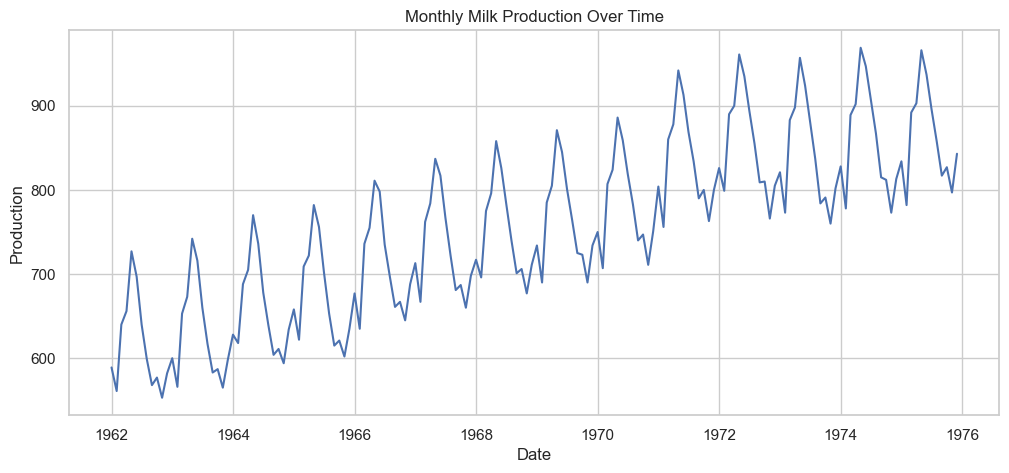

In [7]:
plt.plot(df.index, df["Production"])
plt.title("Monthly Milk Production Over Time")
plt.xlabel("Date")
plt.ylabel("Production")
plt.show()


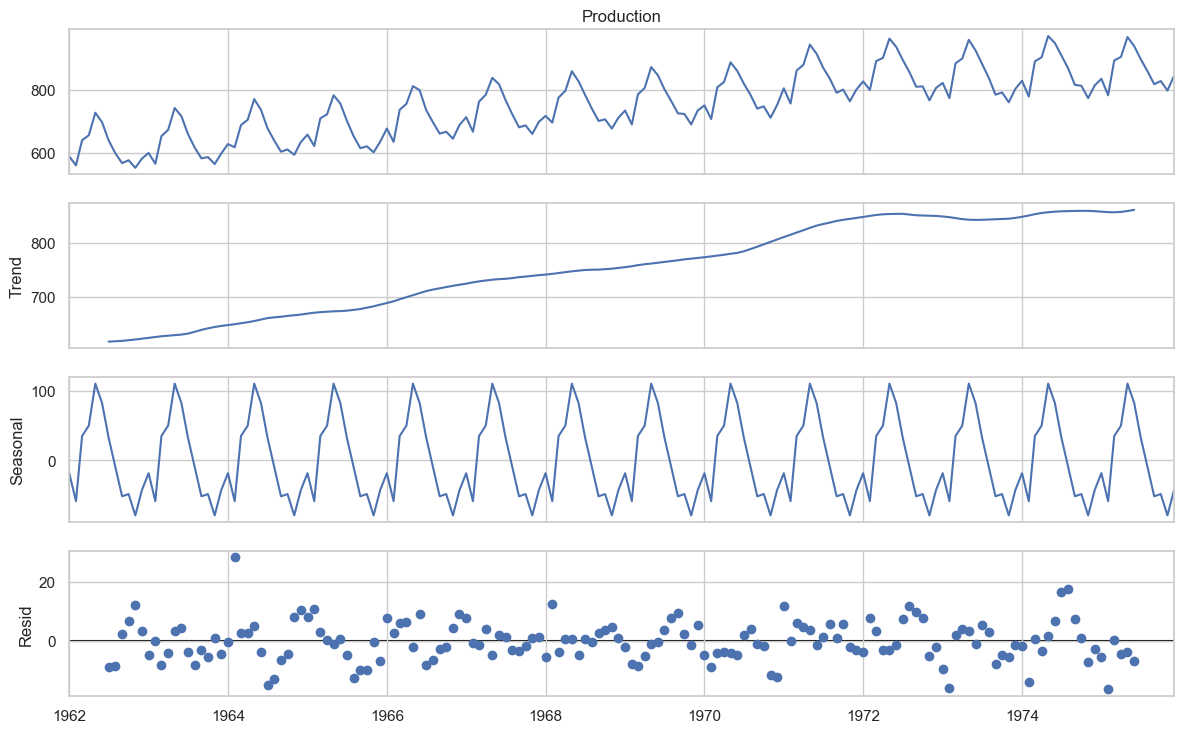

In [8]:
decomposition = seasonal_decompose(df["Production"], model="additive", period=12)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()


In [11]:
Q1 = df["Production"].quantile(0.25)
Q3 = df["Production"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df["Production"] < lower_bound) | (df["Production"] > upper_bound)]
outliers


,Production
Date,


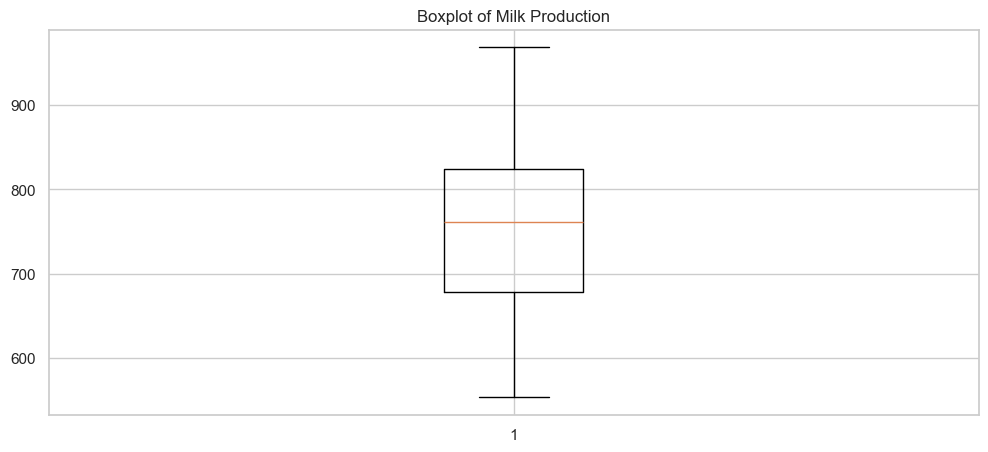

In [12]:
plt.boxplot(df["Production"])
plt.title("Boxplot of Milk Production")
plt.show()


## Step 2: Data Preparation for Deep Learning

In [13]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[["Production"]])


In [14]:
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]
len(train_data), len(test_data)


(134, 34)

In [15]:
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i - window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

window_size = 12
X_train, y_train = create_sequences(train_data, window_size)
X_test, y_test = create_sequences(np.concatenate([train_data[-window_size:], test_data]), window_size)


In [16]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
X_train.shape, X_test.shape


((122, 12, 1), (34, 12, 1))

## Step 3: Model Building

In [17]:
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

def build_rnn():
    model = Sequential([
        SimpleRNN(64, activation="tanh", return_sequences=True, input_shape=(window_size, 1)),
        Dropout(0.2),
        SimpleRNN(32, activation="tanh"),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

def build_lstm():
    model = Sequential([
        LSTM(64, activation="tanh", return_sequences=True, input_shape=(window_size, 1)),
        Dropout(0.2),
        LSTM(32, activation="tanh"),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

def build_gru():
    model = Sequential([
        GRU(64, activation="tanh", return_sequences=True, input_shape=(window_size, 1)),
        Dropout(0.2),
        GRU(32, activation="tanh"),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model


In [18]:
rnn_model = build_rnn()
history_rnn = rnn_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)


C:\Users\Mitali Patil\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
lstm_model = build_lstm()
history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)


In [ ]:
gru_model = build_gru()
history_gru = gru_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)


In [ ]:
plt.plot(history_rnn.history["loss"], label="RNN Train Loss")
plt.plot(history_lstm.history["loss"], label="LSTM Train Loss")
plt.plot(history_gru.history["loss"], label="GRU Train Loss")
plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


## Step 4: Model Evaluation

In [ ]:
def evaluate_model(model, X_test, y_test, scaler):
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_true = scaler.inverse_transform(y_test.reshape(-1, 1))
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return y_true, y_pred, rmse, mae, mape


In [ ]:
y_true_rnn, y_pred_rnn, rmse_rnn, mae_rnn, mape_rnn = evaluate_model(rnn_model, X_test, y_test, scaler)
y_true_lstm, y_pred_lstm, rmse_lstm, mae_lstm, mape_lstm = evaluate_model(lstm_model, X_test, y_test, scaler)
y_true_gru, y_pred_gru, rmse_gru, mae_gru, mape_gru = evaluate_model(gru_model, X_test, y_test, scaler)

results = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],
    "RMSE": [rmse_rnn, rmse_lstm, rmse_gru],
    "MAE": [mae_rnn, mae_lstm, mae_gru],
    "MAPE": [mape_rnn, mape_lstm, mape_gru]
})
results


In [ ]:
test_dates = df.index[train_size:]

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
axes[0].plot(test_dates, y_true_rnn, label="Actual")
axes[0].plot(test_dates, y_pred_rnn, label="RNN Predicted")
axes[0].set_title("RNN: Actual vs Predicted")
axes[0].legend()

axes[1].plot(test_dates, y_true_lstm, label="Actual")
axes[1].plot(test_dates, y_pred_lstm, label="LSTM Predicted")
axes[1].set_title("LSTM: Actual vs Predicted")
axes[1].legend()

axes[2].plot(test_dates, y_true_gru, label="Actual")
axes[2].plot(test_dates, y_pred_gru, label="GRU Predicted")
axes[2].set_title("GRU: Actual vs Predicted")
axes[2].legend()

plt.tight_layout()
plt.show()


In [ ]:
results.set_index("Model")[["RMSE", "MAE", "MAPE"]].plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Error")
plt.show()


## Step 5: Prediction and Visualization (Next 12 Months Forecast)

In [ ]:
best_model_name = results.sort_values("RMSE").iloc[0]["Model"]
best_model = {"RNN": rnn_model, "LSTM": lstm_model, "GRU": gru_model}[best_model_name]
best_model_name


In [ ]:
def forecast_future(model, last_sequence, n_steps, scaler):
    forecast_scaled = []
    current_seq = last_sequence.copy()
    for _ in range(n_steps):
        pred = model.predict(current_seq.reshape(1, window_size, 1), verbose=0)
        forecast_scaled.append(pred[0, 0])
        current_seq = np.append(current_seq[1:], pred, axis=0)
    forecast_scaled = np.array(forecast_scaled).reshape(-1, 1)
    return scaler.inverse_transform(forecast_scaled)


In [ ]:
last_sequence = scaled_data[-window_size:]
n_forecast = 12
forecast = forecast_future(best_model, last_sequence, n_forecast, scaler)

future_dates = pd.date_range(start=df.index[-1] + pd.DateOffset(months=1), periods=n_forecast, freq="MS")
forecast_df = pd.DataFrame({"Production": forecast.flatten()}, index=future_dates)
forecast_df


In [ ]:
n_boot = 50
boot_forecasts = []
for _ in range(n_boot):
    noisy_seq = last_sequence + np.random.normal(0, 0.01, last_sequence.shape)
    boot_forecasts.append(forecast_future(best_model, noisy_seq, n_forecast, scaler).flatten())
boot_forecasts = np.array(boot_forecasts)
lower_ci = np.percentile(boot_forecasts, 5, axis=0)
upper_ci = np.percentile(boot_forecasts, 95, axis=0)


In [ ]:
plt.plot(df.index, df["Production"], label="Historical")
plt.plot(forecast_df.index, forecast_df["Production"], label=f"{best_model_name} Forecast", color="red")
plt.fill_between(forecast_df.index, lower_ci, upper_ci, color="red", alpha=0.2, label="90% Confidence Interval")
plt.title("12-Month Milk Production Forecast")
plt.xlabel("Date")
plt.ylabel("Production")
plt.legend()
plt.show()


## Step 6: Business Insights

- The milk production series shows a clear long-term upward trend along with strong yearly seasonality, with peaks typically occurring in spring/early summer months and troughs in winter months.
- Among the three deep learning models, the model with the lowest RMSE/MAE/MAPE (shown in the results table above) provides the most reliable short-term forecast and is recommended for operational planning.
- The 12-month forecast can be used by the dairy business to plan procurement, storage capacity, workforce scheduling, and distribution logistics ahead of expected seasonal peaks and troughs.
- The confidence interval around the forecast highlights the uncertainty in future predictions; wider intervals in later months suggest the business should revisit and retrain the model periodically as new data becomes available.
- Recommendation: use the forecast to build safety stock ahead of high-demand seasonal peaks, avoid overproduction during low-demand months, and continuously monitor actual vs. forecasted production to trigger model retraining when deviations grow large.